In [ ]:
import matplotlib.pyplot as plt
import numpy as np

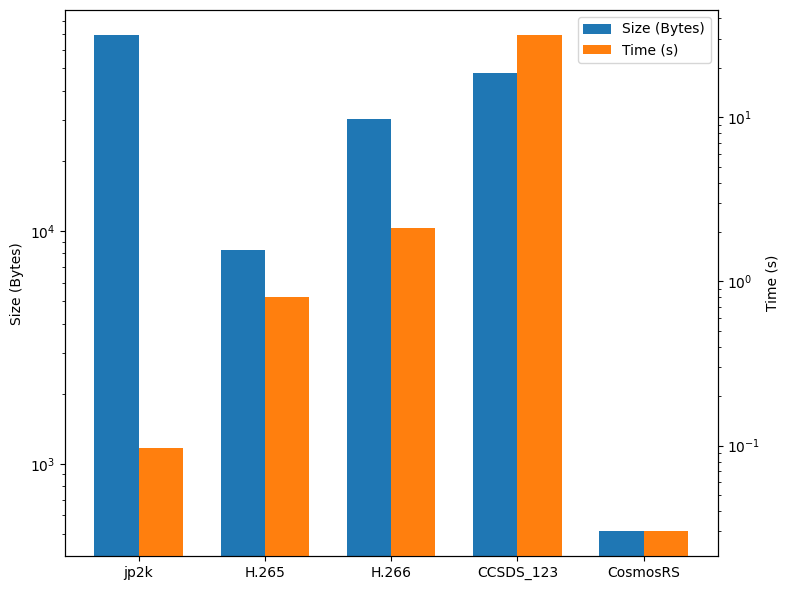

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots(figsize=(8, 6), dpi=100)

names = ["jp2k", "H.265", "H.266", "CCSDS_123", "CosmosRS"]
heights1_size = [69_533, 8_241, 30_251, 47_512, 512]
hights2_time = [0.0963, 0.8, 2.119, 31.76, 0.03]
x = np.arange(len(names))
width = 0.35

rects1 = ax1.bar(x - width / 2, heights1_size, width, label="Size (Bytes)", color="tab:blue")
ax1.set_ylabel("Size (Bytes)")
ax1.set_xticks(x)
ax1.set_xticklabels(names)
ax1.set_yscale("log")  # log scale for size

ax2 = ax1.twinx()
rects2 = ax2.bar(x + width / 2, hights2_time, width, label="Time (s)", color="tab:orange")
ax2.set_ylabel("Time (s)")
ax2.set_yscale("log")  # log scale for time

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.patches import Rectangle


def _annotate_bar(
    ax: Axes,
    rect: Rectangle,
    text: str,
    *,
    color: str,
    x_offset_points: float,
    y_offset_points: float = 4,
    fontsize: float = 12,
    ha: str = "center",
) -> None:
    x = rect.get_x() + rect.get_width() / 2
    y = rect.get_height()
    ax.annotate(
        text,
        xy=(x, y),
        xytext=(x_offset_points, y_offset_points),
        textcoords="offset points",
        ha=ha,
        va="bottom",
        color=color,
        fontsize=fontsize,
        clip_on=False,
    )


def plot_compression_benchmark(
    names: list[str],
    sizes: list[int],
    times: list[float],
    highlight_idx: int = -1,
) -> None:
    """Draws a dual-axis bar chart for compression benchmark.

    Parameters
    ----------
    names : list[str]
        Algorithm names.
    sizes : list[int]
        Output sizes in bytes.
    times : list[float]
        Compression times in seconds.
    highlight_idx : int, optional
        Index to highlight (default: -1, no highlight).
    """
    style = {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial"],
        "axes.labelsize": 13,
        "axes.titlesize": 16,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "figure.dpi": 100,
        "axes.linewidth": 1.2,
    }
    with plt.rc_context(style):
        fig, ax1 = plt.subplots(figsize=(8, 6), dpi=100)
        # Reserve space on the right for the legend (avoid covering the bars/labels).
        fig.subplots_adjust(right=0.80)

        x = np.arange(len(names))
        width = 0.35

        colors_size = ["tab:blue"] * len(names)
        colors_time = ["tab:orange"] * len(names)
        if highlight_idx >= 0:
            colors_size[highlight_idx] = "crimson"
            colors_time[highlight_idx] = "crimson"

        rects1 = ax1.bar(
            x - width / 2,
            sizes,
            width,
            label="Size (Bytes)",
            color=colors_size,
            edgecolor="black",
            linewidth=0.9,
            zorder=3,
        )
        ax1.set_ylabel("Size (Bytes, log scale)")
        ax1.set_yscale("log")
        ax1.set_xticks(x)
        ax1.set_xticklabels(names, rotation=15, ha="right")
        ax1.set_axisbelow(True)
        ax1.grid(True, which="both", axis="y", linestyle="--", linewidth=0.8, alpha=0.35)

        ax2 = ax1.twinx()
        rects2 = ax2.bar(
            x + width / 2,
            times,
            width,
            label="Time (s)",
            color=colors_time,
            edgecolor="black",
            linewidth=0.9,
            zorder=3,
        )
        ax2.set_ylabel("Time (s, log scale)")
        ax2.set_yscale("log")
        ax2.grid(False)

        if highlight_idx >= 0:
            _annotate_bar(
                ax1,
                rects1[highlight_idx],
                f"{sizes[highlight_idx]:,}",
                color="crimson",
                x_offset_points=-5,
                ha="right",
            )
            _annotate_bar(
                ax2,
                rects2[highlight_idx],
                f"{times[highlight_idx]:.3f}",
                color="crimson",
                x_offset_points=5,
                ha="left",
            )

        ax1.spines["top"].set_visible(False)
        ax1.spines["right"].set_visible(False)
        ax2.spines["top"].set_visible(False)
        ax2.spines["right"].set_visible(False)

        handles1, labels1 = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(
            handles1 + handles2,
            labels1 + labels2,
            loc="upper left",
            bbox_to_anchor=(0.3, 1.0),
            frameon=False,
            borderaxespad=0,
        )

        ax1.set_title("Compression Benchmark Comparison", pad=14)
        plt.show()


names = ["jp2k", "H.265", "H.266", "CCSDS_123", "CosmosRS"]
heights1_size = [69_533, 8_241, 30_251, 47_512, 512]
heights2_time = [0.0963, 0.8, 2.119, 31.76, 0.03]
plot_compression_benchmark(names, heights1_size, heights2_time, highlight_idx=4)

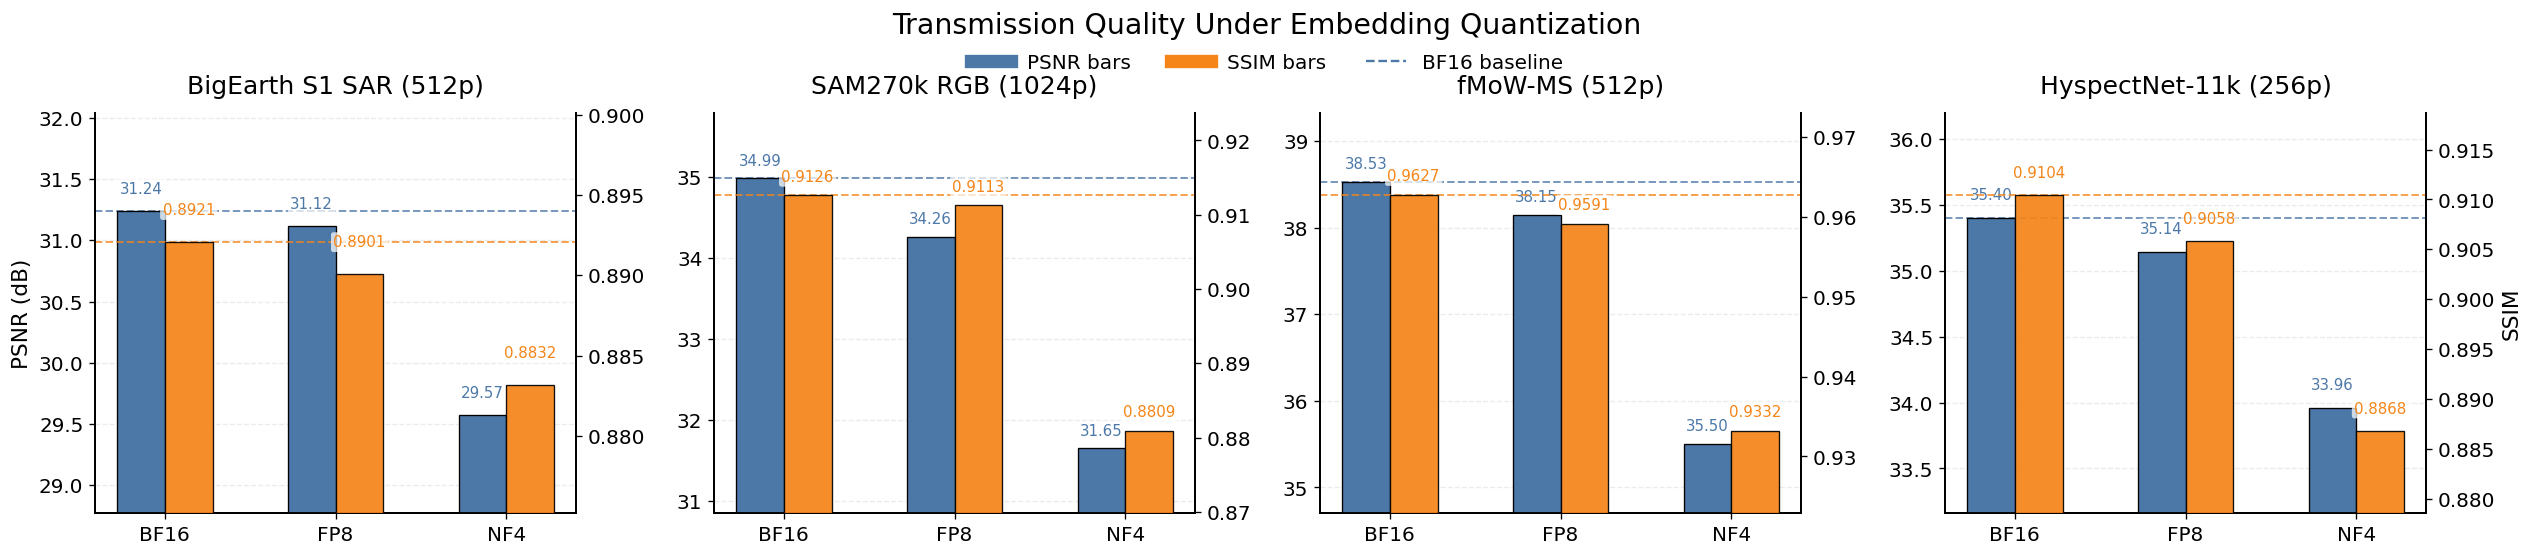

In [27]:
from typing import TypedDict

from matplotlib.lines import Line2D


class MetricBundle(TypedDict, total=False):
    psnr: float
    ssim: float
    sam: float


class TransmissionRecord(TypedDict):
    title: str
    image_size: str
    metrics: dict[str, MetricBundle]


QUANT_ORDER = ["BFloat16", "Latent_FP8", "Latent_NF4"]
QUANT_LABELS = {
    "BFloat16": "BF16",
    "Latent_FP8": "FP8",
    "Latent_NF4": "NF4",
}
PSNR_COLOR = "#4C78A8"
SSIM_COLOR = "#F58518"

transmission_records: list[TransmissionRecord] = [
    {
        "title": "BigEarth S1 SAR",
        "image_size": "512p",
        "metrics": {
            "BFloat16": {"psnr": 31.24, "ssim": 0.8921},
            "Latent_FP8": {"psnr": 31.12, "ssim": 0.8901},
            "Latent_NF4": {"psnr": 29.57, "ssim": 0.8832},
        },
    },
    {
        "title": "SAM270k RGB",
        "image_size": "1024p",
        "metrics": {
            "BFloat16": {"psnr": 34.9851, "ssim": 0.9126},
            "Latent_FP8": {"psnr": 34.2619, "ssim": 0.9113},
            "Latent_NF4": {"psnr": 31.6517, "ssim": 0.8809},
        },
    },
    {
        "title": "fMoW-MS",
        "image_size": "512p",
        "metrics": {
            "BFloat16": {"psnr": 38.5254, "ssim": 0.9627, "sam": 0.0322},
            "Latent_FP8": {"psnr": 38.1510, "ssim": 0.9591, "sam": 0.0320},
            "Latent_NF4": {"psnr": 35.5014, "ssim": 0.9332, "sam": 0.0409},
        },
    },
    {
        "title": "HyspectNet-11k",
        "image_size": "256p",
        "metrics": {
            "BFloat16": {"psnr": 35.3989, "ssim": 0.9104, "sam": 0.0775},
            "Latent_FP8": {"psnr": 35.1448, "ssim": 0.9058, "sam": 0.0777},
            "Latent_NF4": {"psnr": 33.9596, "ssim": 0.8868, "sam": 0.0831},
        },
    },
]


def _axis_limits(values: list[float], *, min_pad: float, pad_ratio: float) -> tuple[float, float]:
    lower = min(values)
    upper = max(values)
    span = max(upper - lower, min_pad)
    pad = max(span * pad_ratio, min_pad)
    return lower - pad, upper + pad


def _annotate_bars(ax, bars, fmt: str, offset: float, color: str) -> None:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            format(height, fmt),
            ha="center",
            va="bottom",
            fontsize=9,
            color=color,
            bbox={"boxstyle": "round,pad=0.16", "facecolor": "white", "edgecolor": "none", "alpha": 0.72},
        )


def plot_transmission_quality_panels(records: list[TransmissionRecord]) -> None:
    style = {
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial"],
        "axes.labelsize": 13,
        "axes.titlesize": 15,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
        "axes.linewidth": 1.1,
        "figure.dpi": 120,
    }

    with plt.rc_context(style):
        fig, axes = plt.subplots(
            1,
            4,
            figsize=(21, 4),
            constrained_layout=True,
            gridspec_kw={"wspace": 0.05},
        )
        bar_width = 0.28

        for idx, (ax, record) in enumerate(zip(axes, records)):
            x = np.arange(len(QUANT_ORDER))
            psnr_values = [record["metrics"][quant]["psnr"] for quant in QUANT_ORDER]
            ssim_values = [record["metrics"][quant]["ssim"] for quant in QUANT_ORDER]

            psnr_min, psnr_max = _axis_limits(psnr_values, min_pad=0.8, pad_ratio=0.20)
            ssim_min, ssim_max = _axis_limits(ssim_values, min_pad=0.008, pad_ratio=0.35)

            psnr_bars = ax.bar(
                x - bar_width / 2,
                psnr_values,
                width=bar_width,
                color=PSNR_COLOR,
                edgecolor="black",
                linewidth=0.8,
                zorder=3,
                label="PSNR" if idx == 0 else None,
            )
            ssim_ax = ax.twinx()
            ssim_bars = ssim_ax.bar(
                x + bar_width / 2,
                ssim_values,
                width=bar_width,
                color=SSIM_COLOR,
                edgecolor="black",
                linewidth=0.8,
                alpha=0.92,
                zorder=3,
                label="SSIM" if idx == 0 else None,
            )

            ax.axhline(psnr_values[0], linestyle="--", linewidth=1.2, color=PSNR_COLOR, alpha=0.75)
            ssim_ax.axhline(ssim_values[0], linestyle="--", linewidth=1.2, color=SSIM_COLOR, alpha=0.75)

            ax.set_title(f"{record['title']} ({record['image_size']})", pad=12)
            ax.set_xticks(x, [QUANT_LABELS[quant] for quant in QUANT_ORDER])
            ax.set_ylim(psnr_min, psnr_max)
            ssim_ax.set_ylim(ssim_min, ssim_max)
            ax.set_axisbelow(True)
            ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.25)
            ax.spines["top"].set_visible(False)
            ssim_ax.spines["top"].set_visible(False)

            if idx == 0:
                ax.set_ylabel("PSNR (dB)")
            if idx == len(axes) - 1:
                ssim_ax.set_ylabel("SSIM")

            _annotate_bars(ax, psnr_bars, ".2f", offset=0.12, color=PSNR_COLOR)
            _annotate_bars(ssim_ax, ssim_bars, ".4f", offset=0.0015, color=SSIM_COLOR)

        legend_handles = [
            Line2D([0], [0], color=PSNR_COLOR, linewidth=8, label="PSNR bars"),
            Line2D([0], [0], color=SSIM_COLOR, linewidth=8, label="SSIM bars"),
            Line2D([0], [0], color=PSNR_COLOR, linestyle="--", linewidth=1.4, label="BF16 baseline"),
        ]
        fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.07), ncol=3, frameon=False)
        fig.suptitle("Transmission Quality Under Embedding Quantization", y=1.12, fontsize=17)
        plt.show()


plot_transmission_quality_panels(transmission_records)